<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/R_codes/LIfe_Expectancy_Data_Analysis_and_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [7]:
install.packages("knitr")
library(knitr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
lexp=read_csv("Life Expectancy Data.csv", show_col_types = FALSE)

In [5]:
head(lexp)

Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,⋯,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65,1154,⋯,6,8.16,65,0.1,584.25921,33736494,17.2,17.3,0.479,10.1
Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62,492,⋯,58,8.18,62,0.1,612.69651,327582,17.5,17.5,0.476,10.0
Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64,430,⋯,62,8.13,64,0.1,631.74498,31731688,17.7,17.7,0.470,9.9
Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67,2787,⋯,67,8.52,67,0.1,669.95900,3696958,17.9,18.0,0.463,9.8
Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68,3013,⋯,68,7.87,68,0.1,63.53723,2978599,18.2,18.2,0.454,9.5
Afghanistan,2010,Developing,58.8,279,74,0.01,79.679367,66,1989,⋯,66,9.20,66,0.1,553.32894,2883167,18.4,18.4,0.448,9.2


In [10]:
dt <- lexp %>%
select(`Life expectancy`, `Adult Mortality`, `infant deaths`, `Hepatitis B`, BMI, Schooling, `percentage expenditure`)

In [13]:
dt %>%
  cor(., use="complete.obs") %>%
  round(.,2) %>%
  kable()



|                       | Life expectancy| Adult Mortality| infant deaths| Hepatitis B|   BMI| Schooling| percentage expenditure|
|:----------------------|---------------:|---------------:|-------------:|-----------:|-----:|---------:|----------------------:|
|Life expectancy        |            1.00|           -0.71|         -0.18|        0.24|  0.51|      0.71|                   0.38|
|Adult Mortality        |           -0.71|            1.00|          0.06|       -0.14| -0.34|     -0.43|                  -0.23|
|infant deaths          |           -0.18|            0.06|          1.00|       -0.22| -0.22|     -0.20|                  -0.08|
|Hepatitis B            |            0.24|           -0.14|         -0.22|        1.00|  0.15|      0.22|                   0.02|
|BMI                    |            0.51|           -0.34|         -0.22|        0.15|  1.00|      0.52|                   0.21|
|Schooling              |            0.71|           -0.43|         -0.20|        0.22| 

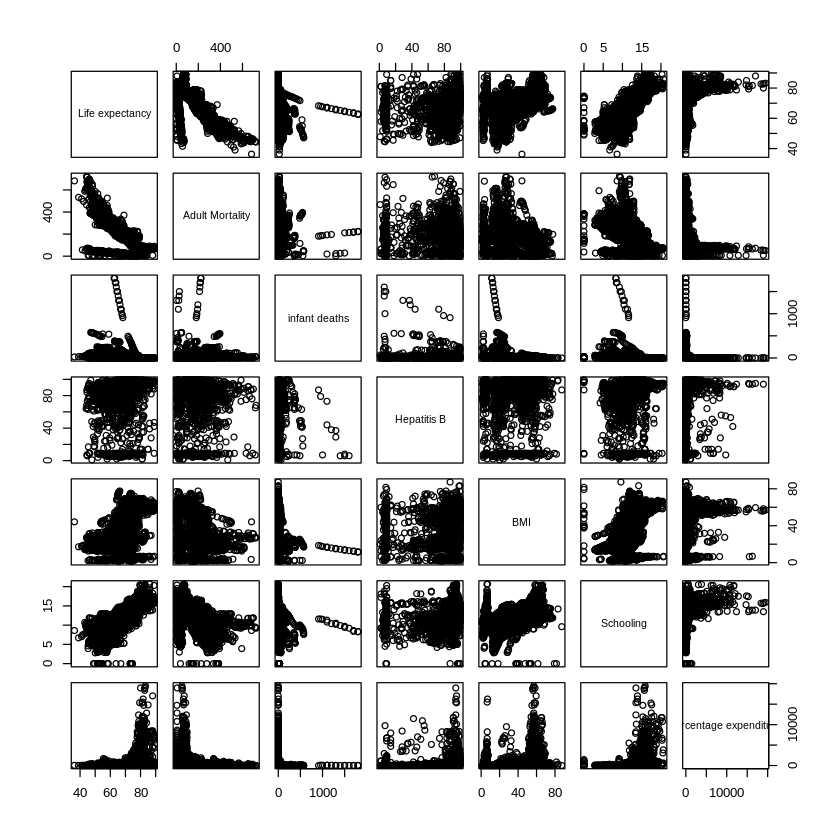

In [14]:
dt %>%
  plot(.)

In [25]:
install.packages("leaps", repos = "http://cran.us.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [29]:
# implementation of the regsubsets in the R
df <- lexp %>%
  select(-c(Country, Year)) %>%
  na.omit()
suppressPackageStartupMessages(library(leaps))
regfit.full <- regsubsets(`Life expectancy` ~ `Adult Mortality` + `infant deaths` + `Hepatitis B` + BMI + Schooling + `percentage expenditure`, data = df)
summary(regfit.full)

Subset selection object
Call: regsubsets.formula(`Life expectancy` ~ `Adult Mortality` + `infant deaths` + 
    `Hepatitis B` + BMI + Schooling + `percentage expenditure`, 
    data = df)
6 Variables  (and intercept)
                         Forced in Forced out
`Adult Mortality`            FALSE      FALSE
`infant deaths`              FALSE      FALSE
`Hepatitis B`                FALSE      FALSE
BMI                          FALSE      FALSE
Schooling                    FALSE      FALSE
`percentage expenditure`     FALSE      FALSE
1 subsets of each size up to 6
Selection Algorithm: exhaustive
         `Adult Mortality` `infant deaths` `Hepatitis B` BMI Schooling
1  ( 1 ) " "               " "             " "           " " "*"      
2  ( 1 ) "*"               " "             " "           " " "*"      
3  ( 1 ) "*"               " "             " "           "*" "*"      
4  ( 1 ) "*"               " "             " "           "*" "*"      
5  ( 1 ) "*"               " "             

In [28]:
install.packages("leaps", repos = "http://cran.us.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [30]:
# sunmmary of the reg
reg.summary <- summary(regfit.full)

In [31]:
names(reg.summary)

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"

In [32]:
reg.summary$rsq

[1] 0.5294455 0.7201407 0.7299954 0.7366396 0.7383714 0.7385657

In [33]:
which.max(reg.summary$adjr2)

[1] 6

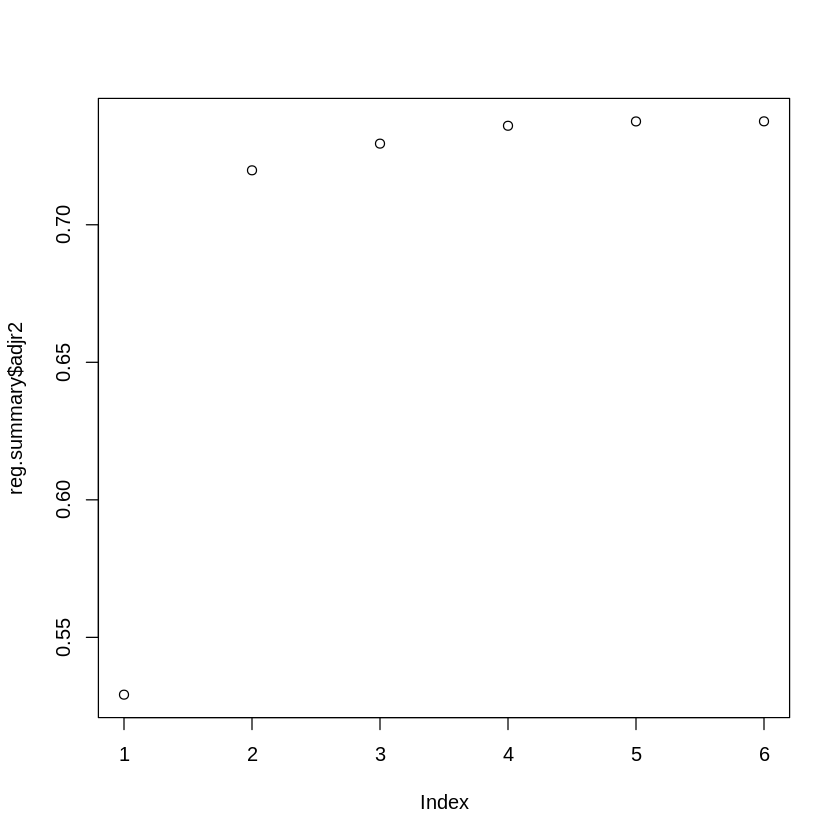

In [35]:
library(ggplot2)
plot(reg.summary$adjr2)

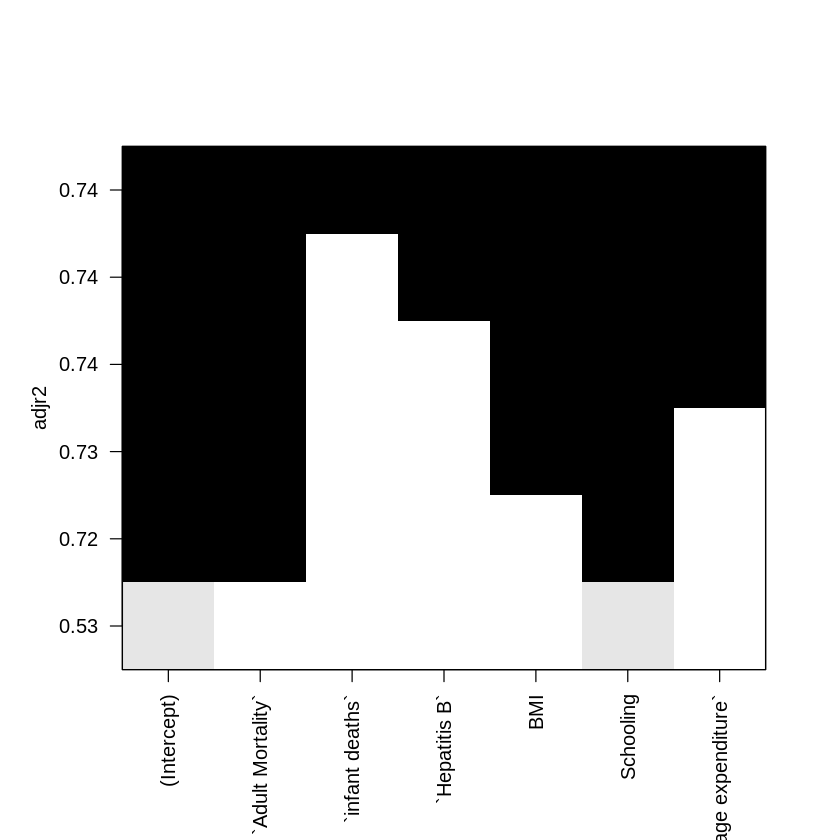

In [36]:
# plot the regfit plot of each column
plot(regfit.full, scale = "adjr2")

In [39]:
# implement the steup wise regression in R
regfit.fwd <- regsubsets(`Life expectancy` ~ `Adult Mortality` + `infant deaths` + `Hepatitis B` + BMI + Schooling + `percentage expenditure`, data=df, nvmax=19, method="forward")
summary(regfit.fwd)
coef(regfit.full, 7)

Subset selection object
Call: regsubsets.formula(`Life expectancy` ~ `Adult Mortality` + `infant deaths` + 
    `Hepatitis B` + BMI + Schooling + `percentage expenditure`, 
    data = df, nvmax = 19, method = "forward")
6 Variables  (and intercept)
                         Forced in Forced out
`Adult Mortality`            FALSE      FALSE
`infant deaths`              FALSE      FALSE
`Hepatitis B`                FALSE      FALSE
BMI                          FALSE      FALSE
Schooling                    FALSE      FALSE
`percentage expenditure`     FALSE      FALSE
1 subsets of each size up to 6
Selection Algorithm: forward
         `Adult Mortality` `infant deaths` `Hepatitis B` BMI Schooling
1  ( 1 ) " "               " "             " "           " " "*"      
2  ( 1 ) "*"               " "             " "           " " "*"      
3  ( 1 ) "*"               " "             " "           "*" "*"      
4  ( 1 ) "*"               " "             " "           "*" "*"      
5  ( 1 ) "*"  

ERROR: Error in s$which[id, , drop = FALSE]: subscript out of bounds


In [40]:
reg.sum <- summary(regfit.fwd)

In [41]:
reg.sum$bic

[1] -1228.272 -2077.726 -2129.431 -2163.109 -2166.580 -2160.397

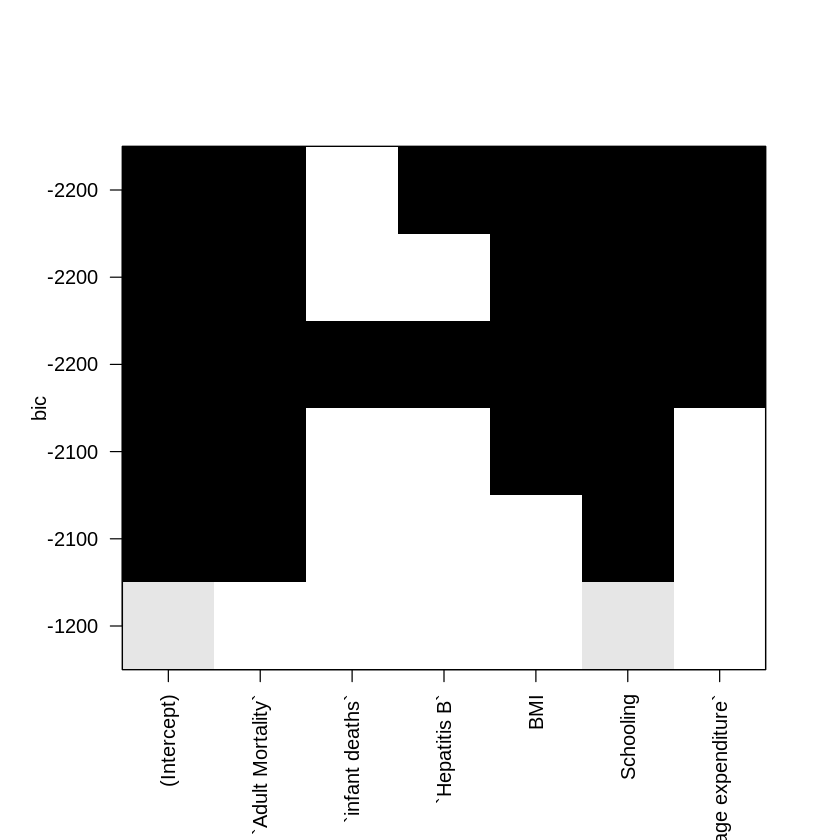

In [42]:
plot(regfit.fwd, scale ="bic")